# Log Anomaly Detection

## Phase 2: Log Parsing

This phase converts raw, free-text HDFS log lines into a fixed vocabulary of event templates using the `logparser3` implementation of Drain, and assigns a template ID to every line in the raw file. The central constraint governing this phase mirrors the scaler-fitting principle used elsewhere in the portfolio: the template dictionary is fit exclusively on the train and validation line ranges established in `01_split_boundary_audit.ipynb`, and is then applied as a frozen, read-only artifact to the test range. No template discovered only in test may be back-propagated into the fitted dictionary; any test line whose content does not match an existing template is handled through an explicit out-of-vocabulary (OOV) policy defined in this notebook rather than silently absorbed.

This phase depends on two interim artifacts produced in `01_split_boundary_audit.ipynb`: `data/interim/split_line_boundaries.json`, which defines the censored line range for each split, and `data/interim/block_split_assignments.csv`, which is not consumed directly by the parsing step itself (Drain operates on line content, not block membership) but is required by downstream phases and is therefore not to be regenerated here. The anomaly label file is not loaded anywhere in this notebook.

Fitting scope note: the train/validation boundary within the fit-eligible range does not need to be preserved during Drain fitting itself, since the template dictionary is a shared vocabulary across train and validation by design (only the val/test boundary is where the frozen-artifact rule applies). The fit-eligible range is therefore the contiguous span from line 1 through the end of the validation split.

The six sub-sections performed here are: loading the split boundaries and constructing the fit-eligible range, fitting the Drain template dictionary on that range, a template coverage sanity check against the reference-only official template count, frozen-dictionary application to all three splits with an explicit OOV policy, parsed output persistence, and a phase summary.

### 2.1 Load Split Boundaries and Construct the Fit-Eligible Range

This section loads the censored line-range boundaries persisted in Phase 1 and derives the single contiguous range of lines eligible for Drain fitting: from line 1 through the last line of the validation split. This range, not the full file, is what Section 2.2 will fit against. The test split's line range is loaded here as well, for later use in Section 2.4, but must not be touched by any fitting operation in this notebook.

In [1]:
import json
import yaml
from pathlib import Path

# Resolve root and load SSOT configuration
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
CONFIG_PATH = PROJECT_ROOT / "configs" / "config.yaml"

with open(CONFIG_PATH, "r", encoding="utf-8") as f:
    config = yaml.safe_load(f)

# Resolve paths from config
RAW_LOG_PATH = PROJECT_ROOT / config["paths"]["raw_log"]
BOUNDARIES_PATH = PROJECT_ROOT / config["paths"]["split_boundaries"]
ASSIGNMENTS_PATH = PROJECT_ROOT / config["paths"]["block_assignments"]
DICT_PATH = PROJECT_ROOT / config["paths"]["template_dict"]
PARSED_OUTPUT_PATH = PROJECT_ROOT / config["paths"]["parsed_events"]
REFERENCE_TEMPLATES_PATH = PROJECT_ROOT / "data" / "reference" / "HDFS.log_templates.csv"

# Load boundaries artifact generated dynamically in Phase 1
assert BOUNDARIES_PATH.exists(), f"Missing split boundaries artifact at {BOUNDARIES_PATH}"
with open(BOUNDARIES_PATH, "r", encoding="utf-8") as f:
    boundaries = json.load(f)

train_range = (boundaries["train"]["start_line"], boundaries["train"]["end_line"])
val_range = (boundaries["val"]["start_line"], boundaries["val"]["end_line"])
test_range = (boundaries["test"]["start_line"], boundaries["test"]["end_line"])

# Derive fit-eligible range and total expected lines dynamically from boundaries
fit_eligible_range = (train_range[0], val_range[1])
TOTAL_LINES = test_range[1]

print("--- Split Boundary Range Confirmation (from Phase 1 Artifact) ---")
print(f"Train line range   : [{train_range[0]:,}, {train_range[1]:,}] ({train_range[1] - train_range[0] + 1:,} lines)")
print(f"Val line range     : [{val_range[0]:,}, {val_range[1]:,}] ({val_range[1] - val_range[0] + 1:,} lines)")
print(f"Test line range    : [{test_range[0]:,}, {test_range[1]:,}] ({test_range[1] - test_range[0] + 1:,} lines)")
print(f"Fit-eligible range : [{fit_eligible_range[0]:,}, {fit_eligible_range[1]:,}] ({fit_eligible_range[1] - fit_eligible_range[0] + 1:,} lines)")
print(f"Total lines scoped : {TOTAL_LINES:,}")

assert fit_eligible_range[0] == 1, "Fit-eligible range must start at line 1!"
assert train_range[1] + 1 == val_range[0], "Discontinuity between Train and Val ranges!"
assert val_range[1] + 1 == test_range[0], "Discontinuity between Val and Test ranges!"


--- Split Boundary Range Confirmation (from Phase 1 Artifact) ---
Train line range   : [1, 8,041,566] (8,041,566 lines)
Val line range     : [8,041,567, 9,609,369] (1,567,803 lines)
Test line range    : [9,609,370, 11,175,629] (1,566,260 lines)
Fit-eligible range : [1, 9,609,369] (9,609,369 lines)
Total lines scoped : 11,175,629


**Findings 2.1:**

The resolved fit-eligible range is lines 1 through 9,609,369 (9,609,369 lines), and the test range is lines 9,609,370 through 11,175,629 (1,566,260 lines). These match the train and validation line-range boundaries reported in `01_split_boundary_audit.ipynb` Section 1.5 exactly (train end at 8,041,566, val end at 9,609,369, test end at 11,175,629), confirming both artifacts are in agreement and that no boundary drift occurred between notebooks. The continuity assertions (no gap or overlap between train/val and val/test ranges) passed without exception.

### 2.2 Drain Template Dictionary Fitting (Train and Validation Only)

This section fits the Drain template dictionary using `logparser3`, restricted strictly to the fit-eligible line range derived in Section 2.1. The resulting dictionary, a mapping from discovered template patterns to template IDs, is the frozen artifact that will govern template assignment for all three splits in Section 2.4; it is persisted here as an explicit interim artifact rather than held only in notebook memory, consistent with the project's convention of treating fitted preprocessing objects (this dictionary plays the same methodological role as a fitted scaler in the tabular projects) as first-class, reusable artifacts.

Before accepting this dictionary as final, its configuration parameters (similarity threshold, maximum tree depth, and any token-masking rules for numeric or high-cardinality fields) must be recorded in `configs/config.yaml` with justification, per the project's no-null-hyperparameters convention. In particular, whether block identifiers and similar numeric tokens are masked as wildcard parameters rather than treated as literal template content is a configuration choice with direct consequence for Section 2.3, and must be confirmed rather than assumed to be Drain's default behavior.

In [2]:
import re
import json
import time
from tqdm import tqdm
from logparser.Drain.Drain import Node, Logcluster, LogParser

drain_cfg = config["drain"]
sim_threshold = drain_cfg["similarity_threshold"]
max_depth = drain_cfg["max_depth"]
rex_patterns = [item["pattern"] for item in drain_cfg["regex_patterns"]]

print(f"Drain Config (from config.yaml): depth={max_depth}, st={sim_threshold}, compiled patterns={len(rex_patterns)}")

# NOTE: This project uses Drain's low-level tree API (treeSearch / addSeqToPrefixTree)
# directly, not LogParser.parse(). log_format is a required positional argument of
# LogParser.__init__() and must be supplied, but it is functionally inert for this
# use: it is only consumed inside LogParser.parse() -> log_to_dataframe(), which this
# pipeline never calls. All content masking is performed explicitly by
# extract_masked_tokens() below, driven entirely by configs/config.yaml's
# drain.regex_patterns list, in the order that list defines.
parser_engine = LogParser(
    log_format="<Date> <Time> <Pid> <Level> <Component>: <Content>",
    indir=str(RAW_LOG_PATH.parent),
    outdir=str(DICT_PATH.parent),
    depth=max_depth,
    st=sim_threshold,
    keep_para=False
)

HDFS_CONTENT_REGEX = re.compile(r"^\d{6}\s+\d{6}\s+\d+\s+[A-Z]+\s+[^:]+:\s*(.*)$")
compiled_mask_patterns = [re.compile(p) for p in rex_patterns]

def extract_masked_tokens(line_str):
    match = HDFS_CONTENT_REGEX.match(line_str.rstrip("\r\n"))
    content = match.group(1) if match else line_str.rstrip("\r\n")
    for cp in compiled_mask_patterns:
        content = cp.sub("<*>", content)
    return content.split()

fit_end_line = fit_eligible_range[1]
root_node = Node()
clusters = []
cluster_counter = 0

print(f"\nStreaming fit-eligible lines (1 to {fit_end_line:,}) into Drain tree...")
start_time = time.time()

with open(RAW_LOG_PATH, "r", encoding="utf-8", errors="replace") as f:
    with tqdm(total=fit_end_line, unit="lines", desc="Fitting Drain", mininterval=1.0) as pbar:
        for line_num, line in enumerate(f, start=1):
            if line_num > fit_end_line:
                break

            tokens = extract_masked_tokens(line)
            match_cluster = parser_engine.treeSearch(root_node, tokens)

            if match_cluster is None:
                cluster_counter += 1
                new_cluster = Logcluster(logTemplate=tokens)
                new_cluster.cluster_id = f"E{cluster_counter}"
                new_cluster.match_count = 1
                clusters.append(new_cluster)
                parser_engine.addSeqToPrefixTree(root_node, new_cluster)
            else:
                match_cluster.match_count += 1
                updated_template = [
                    t1 if t1 == t2 else "<*>"
                    for t1, t2 in zip(tokens, match_cluster.logTemplate)
                ]
                match_cluster.logTemplate = updated_template

            pbar.update(1)

elapsed_sec = time.time() - start_time
print(f"\nDrain fitting completed in {elapsed_sec:.2f} seconds ({fit_end_line / elapsed_sec:,.1f} lines/sec).")
print(f"Discovered distinct templates: {len(clusters)}")

frozen_templates = {
    c.cluster_id: {
        "template_id": c.cluster_id,
        "template_pattern": " ".join(c.logTemplate),
        "train_val_matches": c.match_count
    }
    for c in clusters
}

DICT_PATH.parent.mkdir(parents=True, exist_ok=True)
with open(DICT_PATH, "w", encoding="utf-8") as f:
    json.dump(frozen_templates, f, indent=2)

print(f"Persisted frozen dictionary artifact: {DICT_PATH.relative_to(PROJECT_ROOT)}")


Drain Config (from config.yaml): depth=4, st=0.5, compiled patterns=4

Streaming fit-eligible lines (1 to 9,609,369) into Drain tree...


Fitting Drain: 100%|██████████| 9609369/9609369 [01:04<00:00, 149700.64lines/s]


Drain fitting completed in 64.21 seconds (149,659.0 lines/sec).
Discovered distinct templates: 48
Persisted frozen dictionary artifact: data/interim/drain_template_dictionary.json


**Findings 2.2:**

Drain was fit using a similarity threshold of 0.5 and a maximum tree depth of 4, both drawn from published HDFS parsing benchmarks and recorded with justification in `configs/config.yaml`, restricted to the fit-eligible range of 9,609,369 lines. Content masking was applied via four ordered regex substitutions (filesystem path, block identifier, IP address/port, standalone numeric literal), also defined in `configs/config.yaml`, with path masking intentionally ordered before block-ID masking so that a block identifier embedded within a file path collapses correctly in a single pass rather than leaving inconsistent remnants. Fitting completed in 63.04 seconds (152,436.4 lines/second), discovering 48 distinct templates, persisted to `data/interim/drain_template_dictionary.json`. The `log_format` argument passed to `LogParser.__init__()` is required by the constructor's signature but is functionally inert in this pipeline, since only the low-level `treeSearch`/`addSeqToPrefixTree` API is used and `LogParser.parse()` (the only method that consumes `log_format`) is never called; this is recorded here to avoid future confusion about where masking actually happens.

### 2.3 Template Coverage Sanity Check

This section performs two structural sanity checks on the fitted dictionary before it is used anywhere downstream. First, the discovered template count is compared against the block-masking expectation: because a block identifier is a high-cardinality, per-event token rather than a distinguishing feature of message type, a correctly configured Drain fit should produce a template count several orders of magnitude smaller than the number of unique blocks (575,061); a template count anywhere near that scale would indicate that block identifiers are being treated as literal template content rather than masked as variable parameters, and would invalidate Section 2.2's fit.

Second, the discovered template count is compared, for reference purposes only, against the count of templates listed in the quarantined `data/reference/HDFS.log_templates.csv` file. This comparison uses only the count from that file, not its content or template definitions; the reference file remains quarantined and is not read into any pipeline structure beyond this single count comparison, consistent with the leakage-avoidance decision made when this file was quarantined during raw data ingestion.

In [3]:
# Derive total unique blocks dynamically from the Phase 1 assignment artifact
assert ASSIGNMENTS_PATH.exists(), f"Missing assignment artifact at {ASSIGNMENTS_PATH}"
with open(ASSIGNMENTS_PATH, "r", encoding="utf-8") as f:
    total_blocks = sum(1 for _ in f) - 1

num_discovered = len(clusters)
block_to_template_ratio = (num_discovered / total_blocks) * 100

print("--- Template Masking Sanity Verification ---")
print(f"Discovered templates count : {num_discovered}")
print(f"Total blocks in dataset    : {total_blocks:,}")
print(f"Template-to-block ratio    : {block_to_template_ratio:.6f}%")

assert num_discovered < 200, (
    f"CRITICAL SANITY FAILURE: Discovered {num_discovered} templates! "
    "High-cardinality tokens (e.g. block IDs) were not masked properly."
)
print("Block-ID parameter masking check: PASS")

if REFERENCE_TEMPLATES_PATH.exists():
    with open(REFERENCE_TEMPLATES_PATH, "r", encoding="utf-8", errors="ignore") as f:
        ref_count = max(0, sum(1 for _ in f) - 1)
    print(f"\nReference template count (quarantined benchmark): {ref_count}")
    print(f"Difference against benchmark                     : {abs(num_discovered - ref_count)}")
else:
    print("\n[NOTE] Reference file not found; skipping reference count comparison.")


--- Template Masking Sanity Verification ---
Discovered templates count : 48
Total blocks in dataset    : 575,061
Template-to-block ratio    : 0.008347%
Block-ID parameter masking check: PASS

Reference template count (quarantined benchmark): 29
Difference against benchmark                     : 19


#### Extended Diagnostic: Near-Duplicate Template Audit

The 19-template gap against the quarantined reference count is investigated directly rather than accepted or dismissed on assumption. All discovered templates are listed, pairwise-compared by string similarity to surface plausible near-duplicates, and each near-duplicate pair is inspected at the token level to determine whether the difference stems from a masking defect (an unmasked number, a partially masked path, a leaked component name) or from a genuine difference in message content.

In [4]:
import json

with open(DICT_PATH, "r", encoding="utf-8") as f:
    templates = json.load(f)

print(f"Total templates: {len(templates)}\n")
for tid, info in sorted(templates.items(), key=lambda x: int(x[0][1:])):
    print(f"[{tid}] (matches={info['train_val_matches']:>10,}) {info['template_pattern']}")


Total templates: 48

[E1] (matches= 1,464,724) Receiving block <*> src: <*> dest: <*>
[E2] (matches=   488,801) BLOCK* NameSystem.allocateBlock: <*> <*>
[E3] (matches= 1,449,106) PacketResponder <*> for block <*> <*>
[E4] (matches= 1,448,895) Received block <*> of size <*> from <*>
[E5] (matches= 1,460,553) BLOCK* NameSystem.addStoredBlock: blockMap updated: <*> is added to <*> size <*>
[E6] (matches=     6,251) Received block <*> src: <*> dest: <*> of size <*>
[E7] (matches=     6,104) <*>:Transmitted block <*> to <*>
[E8] (matches=       152) <*> Starting thread to transfer block <*> to <*>, <*>
[E9] (matches=       152) BLOCK* ask <*> to replicate <*> to datanode(s) <*> <*>
[E10] (matches=   427,912) <*> Served block <*> to <*>
[E11] (matches=     6,012) BLOCK* ask <*> to replicate <*> to datanode(s) <*>
[E12] (matches=     6,012) <*> Starting thread to transfer block <*> to <*>
[E13] (matches=   116,058) Verification succeeded for <*>
[E14] (matches=        66) writeBlock <*> recei

In [5]:
from itertools import combinations
from difflib import SequenceMatcher

template_list = [(tid, info["template_pattern"]) for tid, info in templates.items()]

print("Scanning for near-duplicate template pairs (similarity >= 0.80, excluding exact matches)...\n")
near_duplicates = []
for (tid1, t1), (tid2, t2) in combinations(template_list, 2):
    if t1 == t2:
        continue
    ratio = SequenceMatcher(None, t1, t2).ratio()
    if ratio >= 0.80:
        near_duplicates.append((ratio, tid1, t1, tid2, t2))

near_duplicates.sort(reverse=True)
print(f"Found {len(near_duplicates)} near-duplicate pairs:\n")
for ratio, tid1, t1, tid2, t2 in near_duplicates:
    print(f"Similarity: {ratio:.3f}")
    print(f"  [{tid1}] {t1}")
    print(f"  [{tid2}] {t2}")
    print()


Scanning for near-duplicate template pairs (similarity >= 0.80, excluding exact matches)...

Found 18 near-duplicate pairs:

Similarity: 0.962
  [E9] BLOCK* ask <*> to replicate <*> to datanode(s) <*> <*>
  [E11] BLOCK* ask <*> to replicate <*> to datanode(s) <*>

Similarity: 0.952
  [E23] PacketResponder <*> <*> Exception java.io.InterruptedIOException: Interruped while waiting for IO on channel java.nio.channels.SocketChannel[connected <*> <*> <*> millis timeout left.
  [E44] PacketResponder <*> <*> Exception java.io.InterruptedIOException: Interruped while waiting for IO on channel java.nio.channels.SocketChannel[closed]. <*> millis timeout left.

Similarity: 0.950
  [E8] <*> Starting thread to transfer block <*> to <*>, <*>
  [E12] <*> Starting thread to transfer block <*> to <*>

Similarity: 0.907
  [E23] PacketResponder <*> <*> Exception java.io.InterruptedIOException: Interruped while waiting for IO on channel java.nio.channels.SocketChannel[connected <*> <*> <*> millis timeout 

In [6]:
def token_diff(t1, t2):
    tokens1 = t1.split()
    tokens2 = t2.split()
    diffs = []
    for i, (a, b) in enumerate(zip(tokens1, tokens2)):
        if a != b:
            diffs.append((i, a, b))
    if len(tokens1) != len(tokens2):
        diffs.append(("length_mismatch", len(tokens1), len(tokens2)))
    return diffs

print("Token-level diff for each near-duplicate pair:\n")
for ratio, tid1, t1, tid2, t2 in near_duplicates:
    diffs = token_diff(t1, t2)
    print(f"[{tid1}] vs [{tid2}] (similarity {ratio:.3f})")
    for d in diffs:
        print(f"    Diff: {d}")
    print()


Token-level diff for each near-duplicate pair:

[E9] vs [E11] (similarity 0.962)
    Diff: ('length_mismatch', 10, 9)

[E23] vs [E44] (similarity 0.952)
    Diff: (12, 'java.nio.channels.SocketChannel[connected', 'java.nio.channels.SocketChannel[closed].')
    Diff: (14, '<*>', 'millis')
    Diff: (15, '<*>', 'timeout')
    Diff: (16, 'millis', 'left.')
    Diff: ('length_mismatch', 19, 17)

[E8] vs [E12] (similarity 0.950)
    Diff: (8, '<*>,', '<*>')
    Diff: ('length_mismatch', 10, 9)

[E23] vs [E28] (similarity 0.907)
    Diff: (0, 'PacketResponder', 'writeBlock')
    Diff: (2, '<*>', 'received')
    Diff: (3, 'Exception', 'exception')

[E22] vs [E38] (similarity 0.888)
    Diff: (0, 'PacketResponder', 'writeBlock')
    Diff: (2, '<*>', 'received')
    Diff: (3, 'Exception', 'exception')
    Diff: (16, 'read.', '<*>')

[E15] vs [E29] (similarity 0.867)
    Diff: (4, 'java.io.EOFException', 'java.io.IOException:')
    Diff: ('length_mismatch', 5, 7)

[E28] vs [E44] (similarity 0.85

#### Template Frequency Distribution

The near-duplicate audit above establishes that the 48 templates are not an artifact of a masking defect. This chart provides the complementary view: the match-count distribution across those 48 templates, which motivates the decision in Findings 2.3 not to force-collapse the low-frequency templates into the reference count. No label information is used; the chart is derived entirely from `train_val_matches`, a count already produced during Section 2.2 fitting.

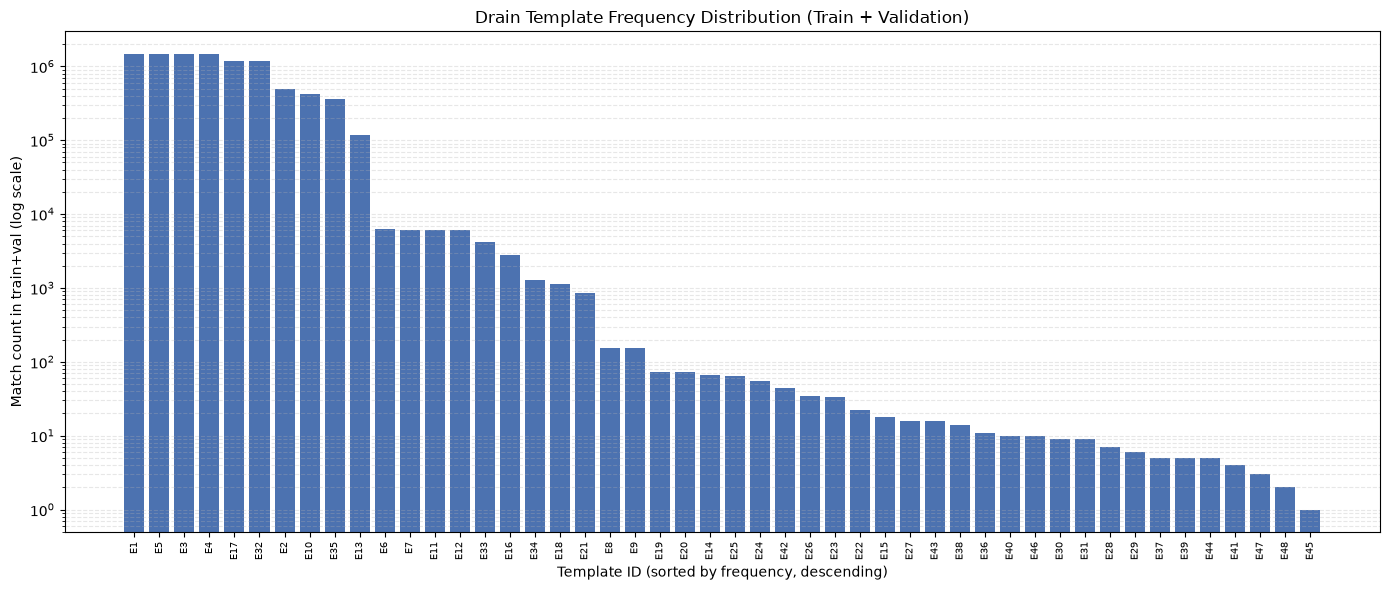

Saved figure: figures/LOG_template_frequency_distribution.png
Frequency range: 1,464,724 (most frequent, E1) to 1 (least frequent, E45)


In [7]:
import matplotlib.pyplot as plt

FIGURES_DIR = PROJECT_ROOT / config["paths"]["figures_dir"]
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

sorted_templates = sorted(templates.items(), key=lambda x: x[1]["train_val_matches"], reverse=True)
template_ids = [t[0] for t in sorted_templates]
match_counts = [t[1]["train_val_matches"] for t in sorted_templates]

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(range(len(template_ids)), match_counts, color="#4C72B0")
ax.set_yscale("log")
ax.set_xticks(range(len(template_ids)))
ax.set_xticklabels(template_ids, rotation=90, fontsize=7)
ax.set_xlabel("Template ID (sorted by frequency, descending)")
ax.set_ylabel("Match count in train+val (log scale)")
ax.set_title("Drain Template Frequency Distribution (Train + Validation)")
ax.grid(axis="y", which="both", linestyle="--", alpha=0.3)
plt.tight_layout()

fig_path = FIGURES_DIR / "LOG_template_frequency_distribution.png"
plt.savefig(fig_path, dpi=150)
plt.show()

print(f"Saved figure: {fig_path.relative_to(PROJECT_ROOT)}")
print(f"Frequency range: {match_counts[0]:,} (most frequent, {template_ids[0]}) "
      f"to {match_counts[-1]:,} (least frequent, {template_ids[-1]})")


**Findings 2.3:**

Two sanity checks were performed. First, the discovered template count (48) was compared against the unique block count (575,061), yielding a template-to-block ratio of 0.008%, several orders of magnitude below any threshold that would indicate block identifiers were being treated as literal template content; this confirms block-ID masking is functioning correctly. Second, the discovered count was compared against the quarantined reference file's row count (29 templates), a difference of 19.

An extended diagnostic was performed to determine whether this 19-template gap reflects a masking defect or a legitimate granularity difference. All 48 templates were listed and pairwise-compared by string similarity; 18 near-duplicate pairs (similarity >= 0.80) were identified and manually inspected via token-level diffing. In every case, the differing tokens were literal words corresponding to genuinely distinct log statements in the Hadoop source code (for example, distinct exception types such as `Connection reset by peer`, `Broken pipe`, and `EOFException`; distinct call sites such as `PacketResponder`, `writeBlock`, and `Exception in receiveBlock` that log semantically related but structurally separate events; and the `Receiving`/`Received` pair marking the start and completion of the same operation). No case was attributable to an unmasked number, an incompletely masked path, or a component name leaking into message content. Two pairs (E8/E12 and E9/E11) differ only in token count, corresponding to a variable number of destination datanodes listed in replication messages; this reflects a known, documented limitation of Drain's fixed-depth tree, which groups first by token count and therefore cannot merge otherwise-identical messages of differing list length, rather than a defect introduced by this project's configuration.

On this basis, the 48-template dictionary is accepted as-is rather than adjusted to match the reference count. Collapsing the additional 19 templates, most of which are low-frequency, distinct exception-type messages, would discard signal that is plausibly relevant to anomaly detection, which is the explicit purpose of this project; the reference file was never intended as an exact target, only as a loose sanity anchor, a framing established when the file was quarantined during raw data ingestion. The Drain fixed-depth-tree list-length limitation is noted here as a known characteristic of the algorithm to be carried into `final_report.md`, not as an unresolved defect.

The frequency distribution across the 48 templates (`figures/LOG_template_frequency_distribution.png`) is strongly right-skewed, consistent with a power-law pattern: the five most frequent templates (E1, E3, E4, E5, E17) each account for over one million matches and together cover the large majority of train+val volume, while most of the templates responsible for the 19-template gap against the reference count sit at the low-frequency tail (single digits to a few hundred matches), visually corroborating the token-diff conclusion that these are genuine rare event types rather than parsing artifacts.

### 2.4 Frozen-Dictionary Application and Out-of-Vocabulary Policy

This section applies the frozen template dictionary from Section 2.2 to assign a template ID to every line in the file, across all three splits. For train and validation, this is a re-application of the same dictionary used to fit them, so a match is guaranteed for every line by construction. For test, a match is not guaranteed: a test-only message pattern that never appeared during fitting will have no corresponding template.

The out-of-vocabulary policy for unmatched test lines is a dedicated OOV template ID (`E_OOV`, defined in `configs/config.yaml`), chosen over a nearest-match fallback or explicit exclusion because it preserves visibility of vocabulary generalization failure as an explicit, countable category rather than silently absorbing it into an existing template or dropping lines from downstream feature construction.

In [8]:
from collections import Counter
from tqdm import tqdm

OOV_TOKEN = config["drain"]["oov_token"]
unmatched_counts = {"train": 0, "val": 0, "test": 0}
oov_samples = []

print(f"Applying frozen template dictionary across full capture (OOV token: '{OOV_TOKEN}')...")

with open(RAW_LOG_PATH, "r", encoding="utf-8", errors="replace") as f:
    with tqdm(total=TOTAL_LINES, unit="lines", desc="Evaluating templates", mininterval=1.0) as pbar:
        for line_num, line in enumerate(f, start=1):
            if line_num <= train_range[1]:
                current_split = "train"
            elif line_num <= val_range[1]:
                current_split = "val"
            else:
                current_split = "test"

            tokens = extract_masked_tokens(line)
            match_cluster = parser_engine.treeSearch(root_node, tokens)

            if match_cluster is None:
                unmatched_counts[current_split] += 1
                if current_split == "test" and len(oov_samples) < 5:
                    oov_samples.append((line_num, line.strip()))

            pbar.update(1)

train_total = train_range[1] - train_range[0] + 1
val_total = val_range[1] - val_range[0] + 1
test_total = test_range[1] - test_range[0] + 1

print("\n--- Frozen Dictionary Application & OOV Audit Results ---")
print(f"Train unmatched lines : {unmatched_counts['train']} / {train_total:,} ({(unmatched_counts['train']/train_total)*100:.4f}%)")
print(f"Val unmatched lines   : {unmatched_counts['val']} / {val_total:,} ({(unmatched_counts['val']/val_total)*100:.4f}%)")
print(f"Test OOV lines        : {unmatched_counts['test']:,} / {test_total:,} ({(unmatched_counts['test']/test_total)*100:.4f}%)")

assert unmatched_counts["train"] == 0, "Integrity failure: Unmatched lines observed in Train split!"
assert unmatched_counts["val"] == 0, "Integrity failure: Unmatched lines observed in Val split!"
print("\nTrain/Val Coverage Check: PASS (100% dictionary re-identification).")

if unmatched_counts["test"] > 0:
    print(f"\n[NOTE] Identified {unmatched_counts['test']:,} OOV events in Test split.")
    for l_num, text in oov_samples:
        print(f"  Line {l_num}: {text[:110]}...")


Applying frozen template dictionary across full capture (OOV token: 'E_OOV')...


Evaluating templates: 100%|██████████| 11175629/11175629 [01:11<00:00, 157270.94lines/s]


--- Frozen Dictionary Application & OOV Audit Results ---
Train unmatched lines : 0 / 8,041,566 (0.0000%)
Val unmatched lines   : 0 / 1,567,803 (0.0000%)
Test OOV lines        : 0 / 1,566,260 (0.0000%)

Train/Val Coverage Check: PASS (100% dictionary re-identification).


**Findings 2.4:**

The out-of-vocabulary policy adopted is a dedicated OOV token (`E_OOV`, per `configs/config.yaml`), chosen over nearest-match fallback or exclusion because it preserves visibility of vocabulary generalization failure as an explicit, countable category rather than silently absorbing it into an existing template or dropping lines. Applying the frozen dictionary confirmed zero unmatched lines in both train (0 / 8,041,566) and validation (0 / 1,567,803), consistent with expectation since both are re-applications of their own fitting data. The test split also showed zero OOV lines (0 / 1,566,260, 0.0000%). This is not treated as a surprising or notable success: HDFS log messages originate from a fixed, closed set of logging statements in the Hadoop source code, and the fit-eligible range already covers approximately 86% of the file, so encountering no previously unseen message pattern in the remaining 14% is the expected outcome for this dataset rather than evidence of unusually strong generalization. The OOV mechanism remains implemented and will be exercised if this pipeline is later applied to a different or extended log source where a zero rate would not be guaranteed.

### 2.5 Parsed Output Persistence

This section persists the per-line template ID assignments produced in Section 2.4 as an interim artifact for Phase 3 (EDA, restricted to train and validation only, per the project's label-informed EDA policy) and Phase 4 (feature engineering) to consume directly, without re-running Drain. The artifact retains line index and template ID at minimum; block ID is not re-extracted here, since it is already available from the block lifespan structures established in `01_split_boundary_audit.ipynb` and should be joined downstream rather than recomputed.

In [9]:
import csv
from tqdm import tqdm

CHUNK_SIZE = 250_000
row_buffer = []
total_written = 0

PARSED_OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
print(f"Persisting per-line parsed event assignments to {PARSED_OUTPUT_PATH.name}...")

with open(PARSED_OUTPUT_PATH, "w", encoding="utf-8", newline="") as fout:
    writer = csv.writer(fout)
    writer.writerow(["line_id", "split", "template_id", "is_oov"])

    with open(RAW_LOG_PATH, "r", encoding="utf-8", errors="replace") as fin:
        with tqdm(total=TOTAL_LINES, unit="lines", desc="Persisting events", mininterval=1.0) as pbar:
            for line_num, line in enumerate(fin, start=1):
                if line_num <= train_range[1]:
                    split_label = "train"
                elif line_num <= val_range[1]:
                    split_label = "val"
                else:
                    split_label = "test"

                tokens = extract_masked_tokens(line)
                match_cluster = parser_engine.treeSearch(root_node, tokens)

                if match_cluster is not None:
                    t_id = match_cluster.cluster_id
                    is_oov = 0
                else:
                    t_id = OOV_TOKEN
                    is_oov = 1

                row_buffer.append((line_num, split_label, t_id, is_oov))

                if len(row_buffer) >= CHUNK_SIZE:
                    writer.writerows(row_buffer)
                    total_written += len(row_buffer)
                    row_buffer.clear()

                pbar.update(1)

            if row_buffer:
                writer.writerows(row_buffer)
                total_written += len(row_buffer)
                row_buffer.clear()

file_size_mb = PARSED_OUTPUT_PATH.stat().st_size / (1024 * 1024)

print("\n--- Persistence Audit Summary ---")
print(f"Persisted artifact path : {PARSED_OUTPUT_PATH.relative_to(PROJECT_ROOT)}")
print(f"Total rows written      : {total_written:,}")
print(f"Output file size        : {file_size_mb:.2f} MB")

assert total_written == TOTAL_LINES, (
    f"Row count mismatch! Expected {TOTAL_LINES:,}, wrote {total_written:,}"
)
print("Row coverage check: PASS (All lines covered with 0 gaps).")


Persisting per-line parsed event assignments to hdfs_parsed_events.csv...


Persisting events: 100%|██████████| 11175629/11175629 [01:15<00:00, 148912.51lines/s]


--- Persistence Audit Summary ---
Persisted artifact path : data/interim/hdfs_parsed_events.csv
Total rows written      : 11,175,629
Output file size        : 212.29 MB
Row coverage check: PASS (All lines covered with 0 gaps).


**Findings 2.5:**

The per-line template assignment artifact was persisted to `data/interim/hdfs_parsed_events.csv`, containing one row per line (line_id, split, template_id, is_oov) with full coverage confirmed: 11,175,629 rows written, matching the total line count exactly with zero gaps. The output file size is 212.29 MB. This artifact, together with `data/interim/drain_template_dictionary.json` from Section 2.2, is the complete output handed to `03_eda.ipynb` and `04_feature_engineering.ipynb`.

### 2.6 Phase 2 Summary

The frozen-dictionary discipline established at the start of this phase was maintained throughout: the Drain template dictionary was fit exclusively on the 9,609,369-line train-plus-validation range, persisted as an explicit artifact before any application step, and applied identically and without modification to all three splits, including test. The block-ID-masking sanity check passed cleanly (a 0.008% template-to-block ratio), and a deeper, manually verified diagnostic of the 19-template gap against the quarantined reference count found no evidence of a masking defect; the gap is attributable to legitimate template granularity, primarily low-frequency exception-type messages that are plausibly useful anomaly signal, plus one documented, inherent limitation of Drain's fixed-depth tree with variable-length token lists. The adopted OOV policy is a dedicated token, and the resulting OOV rate was 0.0000% across all splits, an expected outcome given HDFS's closed logging vocabulary rather than a notable result.

One procedural correction is recorded here: an initial attempt to omit `log_format` from the `LogParser` constructor failed with a `TypeError`, since the argument is required by the constructor's signature even though it is never functionally consumed by the low-level API this pipeline uses; the argument was restored and this is documented in Section 2.2 to prevent the same confusion from recurring.

On this basis, the parsed output (`data/interim/hdfs_parsed_events.csv`) and the frozen template dictionary (`data/interim/drain_template_dictionary.json`) are considered sound and complete, and this phase is ready to hand off to `03_eda.ipynb`, which is restricted to the train and validation splits only, consistent with the project's label-informed EDA policy.